In [ ]:
fruit_list = ["apple", "banana", "orange"]
print(fruit_list[0])  # 첫 번째 아이템
print(fruit_list[-1])  # 마지막 아이템
print(fruit_list[1:3] )   # 범위 지정 0, 1, 2

apple
orange
['banana', 'orange']


In [11]:
import seaborn as sns
df = sns.load_dataset("tips")
df
# df.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
sns.get_dataset_names()

# 기본 히트맵 생성

In [ ]:
# tip의 평균값(pivot), day(pivot 2차원테이블로 생성하고 day를 행의 인덱스로, size를 열)
# 두번째 매개변수(행 x축), 세번째 매개변수(열 y축)
# 같은 값을 그룹핑해서 평균을 구해서 하나의 값으로 셋팅(새로운 테이블 생성 -> 유의미한 값을 추적)

pivot_df = df.pivot_table('tip', 'day', 'size', observed=True) 
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0


<Axes: xlabel='size', ylabel='day'>

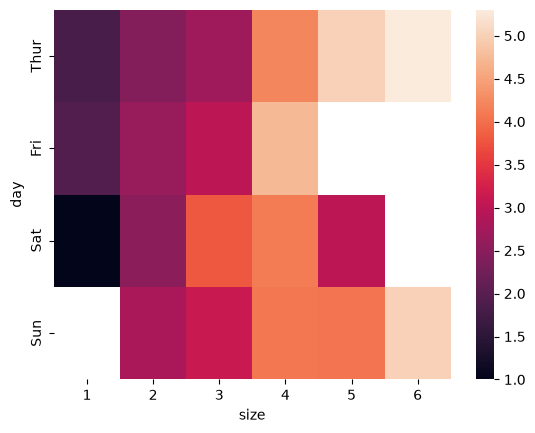

In [5]:
sns.heatmap(pivot_df)

# 히트맵 값 표시

<Axes: xlabel='size', ylabel='day'>

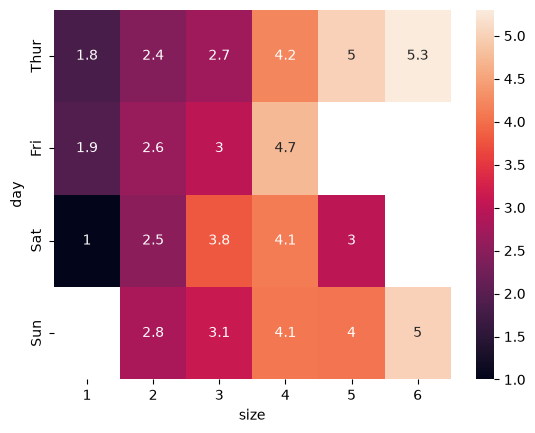

In [12]:
sns.heatmap(pivot_df, annot=True)

# 색상 팔레트 커스터마이징

<Axes: xlabel='size', ylabel='day'>

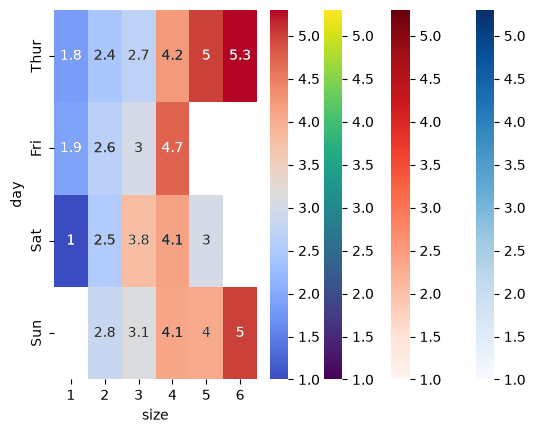

In [28]:
# 다양한 색상 팔레트
sns.heatmap(pivot_df, annot=True, cmap='Blues')
sns.heatmap(pivot_df, annot=True, cmap='Reds')
sns.heatmap(pivot_df, annot=True, cmap='viridis')
sns.heatmap(pivot_df, annot=True, cmap='coolwarm')

# 색상 범위 조정

<Axes: xlabel='size', ylabel='day'>

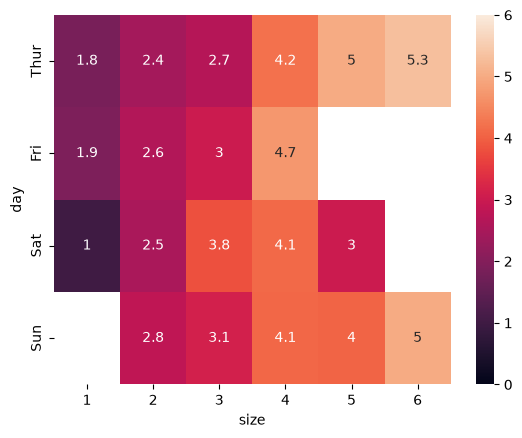

In [23]:
# 색상 범위 고정
sns.heatmap(pivot_df, annot=True, vmin=0, vmax=6)

<Axes: xlabel='size', ylabel='day'>

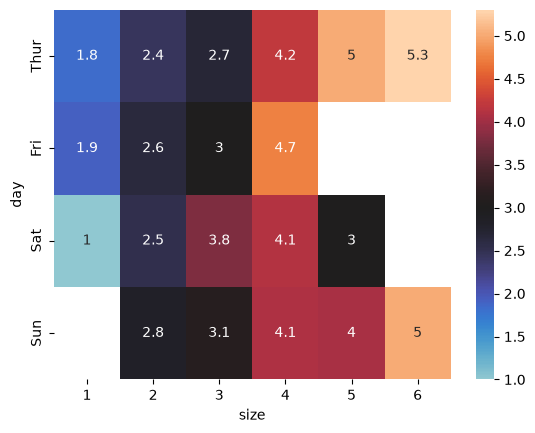

In [35]:
# 중심값 설정

sns.heatmap(pivot_df, annot=True, center=3)

# 색상바와 격자 설정

<Axes: xlabel='size', ylabel='day'>

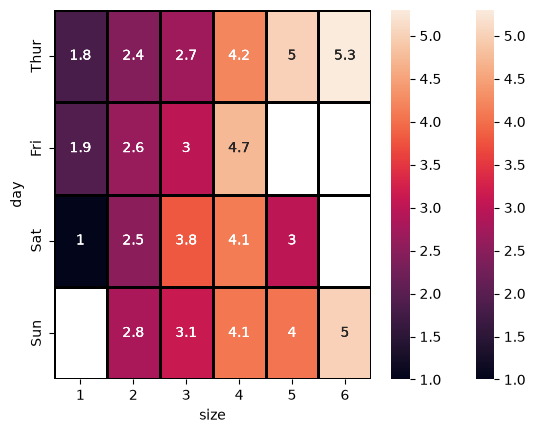

In [44]:
# 색상바 제거
sns.heatmap(pivot_df, annot=True, cbar=False)

# 격자선 추가
sns.heatmap(pivot_df, annot=True, linewidths=0.5, linecolor='white')

# 격자 색상 변경
sns.heatmap(pivot_df, annot=True, linewidths=1, linecolor='black')


# 상관관계 히트맵

<Axes: >

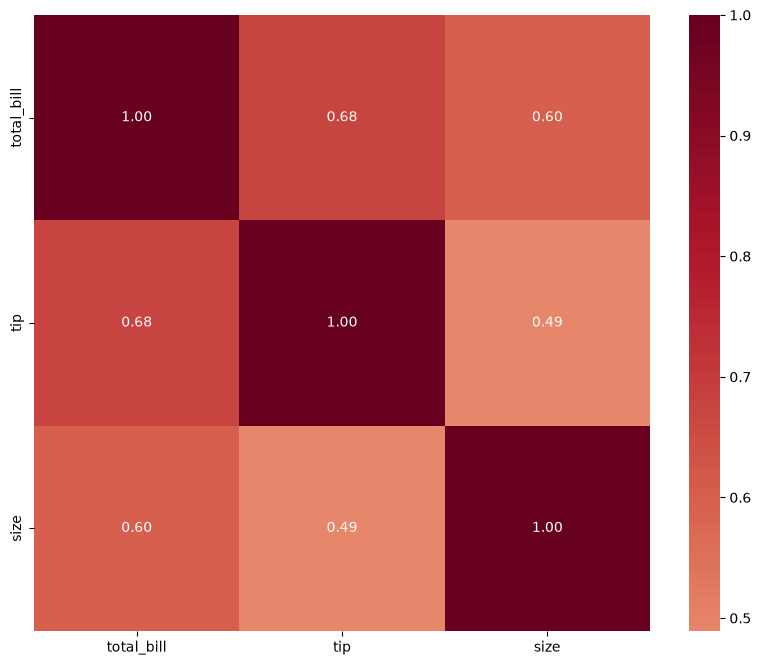

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 숫자형 변수들의 상관관계
numeric_df = df.select_dtypes(include=[np.number]) # 숫자형 데이터
# print(numeric_df)
correlation_matrix = numeric_df.corr() # corr() 상관계수 correlation
# print(correlation_matrix)

# # 상관관계 히트맵
# 상관계수(-1 부터 1 : 1(상관관계 있음), 0(전혀 상관관계 없음), -1(완전히 반대인 성향: 설사약과 변비약))
plt.figure(figsize=(10, 8))
# plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, 
            annot=True,           # 값 표시
            cmap='RdBu_r',       # 빨강-파랑 역순 (-1 에서 1)
            center=0,            # 0을 중심으로
            square=True,         # 정사각형 셀
            fmt='.2f')           # 소수점 2자리

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


<Axes: >

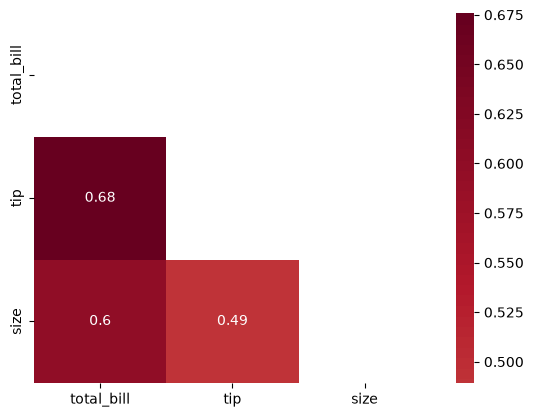

In [55]:
# 상삼각형만 표시 (중복 제거)
import numpy as np

print(correlation_matrix)
# correlation_matrix 3행3열 matrix
# 1로 채워진 상태에서 0이외의 값은 True, 나머지는 False (대각선 기준으로 위쪽은 True로 아래쪽은 False로 채워줌) 
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # triu(상삼각형) True로 셋팅된 부분은 masking(가려짐)
# print(mask)
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r',
            center=0)


<Axes: xlabel='time', ylabel='day'>

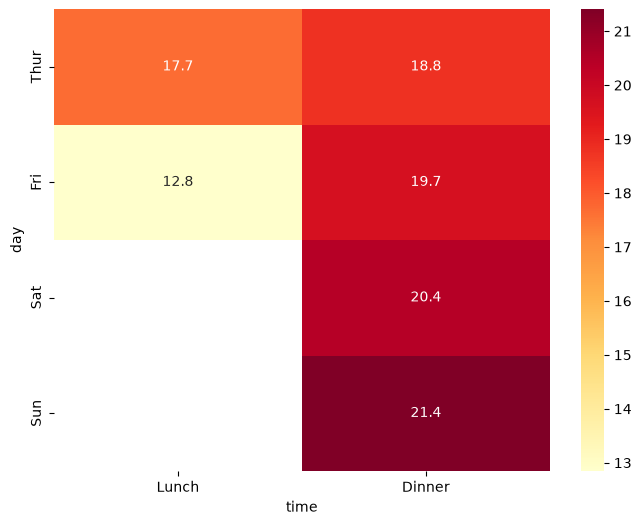

In [57]:
# 요일과 시간대별 평균 계산서
time_day_pivot = df.pivot_table('total_bill', 'day', 'time')  # 평균값, 행, 열

plt.figure(figsize=(8, 6))
sns.heatmap(time_day_pivot, 
            annot=True, 
            fmt='.1f',
            cmap='YlOrRd') # 시각화
            # cmap='YlOrRd_r') # 역순 


c:\workspaces\dataAnalysis\src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\workspaces\dataAnalysis\src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\workspaces\dataAnalysis\src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54017 (\N{HANGUL SYLLABLE TIB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\workspaces\dataAnalysis\src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\workspaces\dataAnalysis\src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\workspaces\dataAnalysis\src\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning

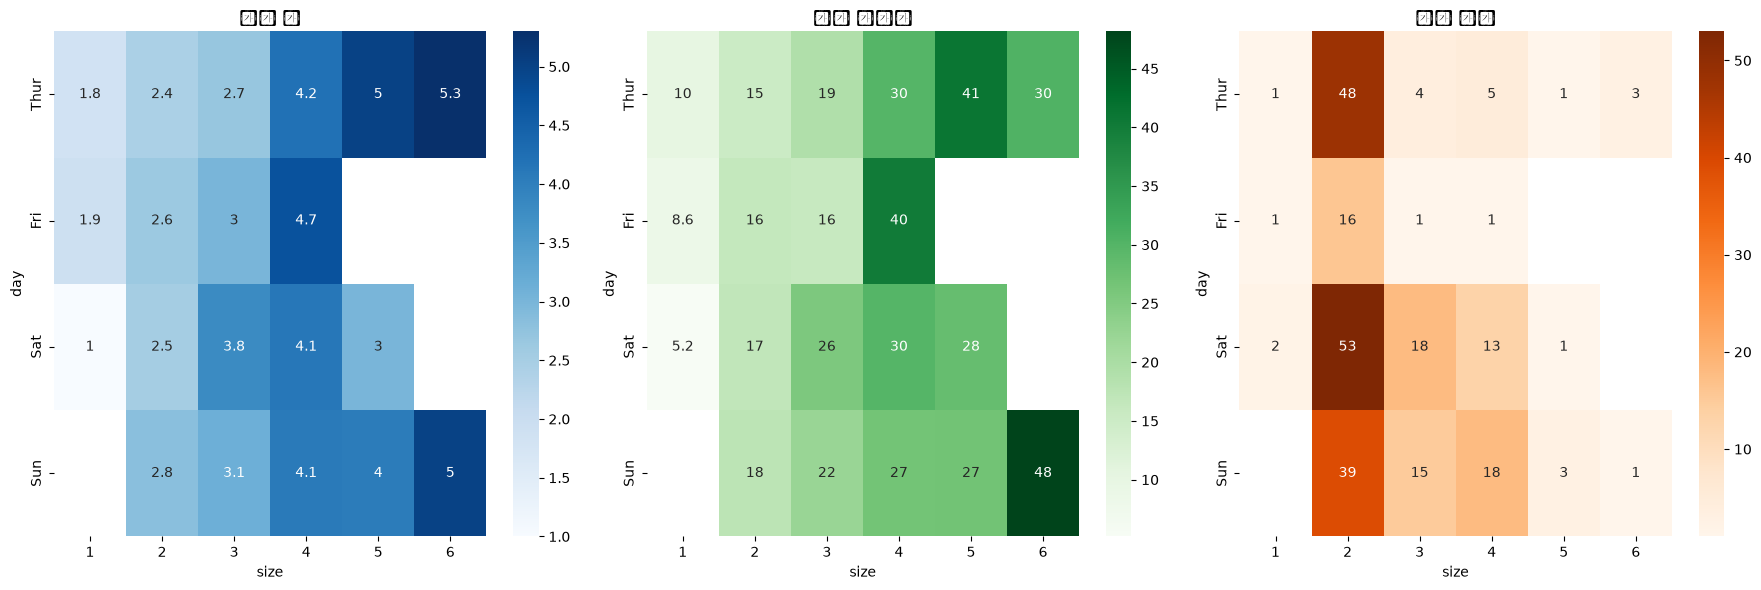

In [13]:
# 여러 지표를 동시에 표시
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 평균 팁
tip_pivot = df.pivot_table('tip', 'day', 'size')
sns.heatmap(tip_pivot, annot=True, ax=axes[0], cmap='Blues')
axes[0].set_title('평균 팁')

# 평균 계산서
bill_pivot = df.pivot_table('total_bill', 'day', 'size')
sns.heatmap(bill_pivot, annot=True, ax=axes[1], cmap='Greens')
axes[1].set_title('평균 계산서')

# 방문 횟수
count_pivot = df.pivot_table('tip', 'day', 'size', aggfunc='count')
sns.heatmap(count_pivot, annot=True, ax=axes[2], cmap='Oranges')
axes[2].set_title('방문 횟수')

plt.tight_layout()

<Axes: xlabel='size', ylabel='day'>

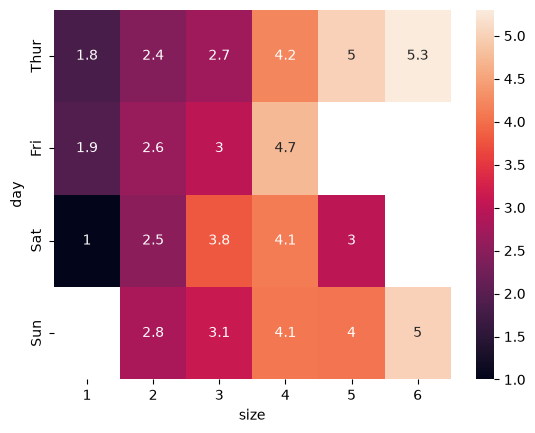

In [14]:
# 카테고리 순서 지정
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
size_order = [1, 2, 3, 4, 5, 6]

# 순서가 지정된 피봇 테이블
pivot_ordered = df.pivot_table('tip', 'day', 'size')
pivot_ordered = pivot_ordered.reindex(day_order)
pivot_ordered = pivot_ordered.reindex(columns=size_order)

sns.heatmap(pivot_ordered, annot=True)